# PARCAST — $E_\mathrm{s}(\mathrm{PAR})$ surface reference

Standalone above-water logger: incident PAR over time, **no depth**, **no
immersion correction** (it sits in air). All logic lives in `parcast_io.py`.

**Run before `PARcast_EdzPAR-v6.ipynb`** — it exports the cloud index.

`pip install pvlib`

## Deployment sites

Site coordinates, time zone and logger clock live in `pio.SITES`; the config cell
above selects one with `SITE = "<key>"`. **RTC** is what the profiler's clock was
set to on that deployment, which is what `pio.clock_shift_h()` converts from.

| key | site | lat | lon | tz | RTC |
| --- | --- | ---: | ---: | --- | --- |
| `galveston` | Galveston, Gulf of Mexico | 29.3100 | -94.7700 | America/Chicago | local |
| `laguna` | Laguna Beach, CA | 33.5427 | -117.7854 | America/Los_Angeles | local |
| `tahoe` | North Lake Tahoe, NV | 39.1988 | -119.9300 | America/Los_Angeles | local |
| `sbc` | Santa Barbara Channel | 34.2114 | -119.9371 | America/Los_Angeles | UTC |
| `malibu` | Malibu, CA | 34.0375 | -118.6775 | America/Los_Angeles | UTC |


## Config

In [30]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, ".")          # folder holding parcast_io.py
import parcast_io as pio

def version_tuple(v):
    """Numeric version for comparison, so that 6.10 sorts after 6.9."""
    return tuple(int(part) for part in str(v).split("."))

# This notebook needs parcast_io.py v6.7 or later. If the assert fails you are
# running an older copy of the module - replace the file and restart the kernel.
assert version_tuple(getattr(pio, "__version__", "0")) >= (6, 7), (
    f"parcast_io.py is v{getattr(pio,'__version__','<6.7, no version marker')} "
    "- replace it with the v6.7 file and restart the kernel")
print(f"parcast_io v{pio.__version__}")

%matplotlib inline
plt.rcParams.update(pio.PUB_RC)

ES_SURFACE_CSV = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_sPAR/E_sPAR_20260811_0001.CSV'
ED_DIR         = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_dzPAR'
FIG_BASE       = '/Users/loriberberian/Desktop/PARcast/data_processing/figures'

# ---- site ------------------------------------------------------------------
# Edit these four lines. The other sites are listed below, copy one across.
#
#   site                        lat        lon      tz                   RTC
#   Galveston, Gulf of Mexico   29.3100    -94.7700  America/Chicago      local
#   Laguna Beach, CA            33.5427   -117.7854  America/Los_Angeles  local
#   North Lake Tahoe, NV        39.1988   -119.9300  America/Los_Angeles  local
#   Santa Barbara Channel       34.2114   -119.9371  America/Los_Angeles  utc
#   Malibu, CA                  34.0375   -118.6775  America/Los_Angeles  utc
#
# Galveston, Laguna and Tahoe are landmark centroids pending the field positions.
# Solar zenith angle moves about 0.1 deg per 0.1 deg of position, so they are
# close enough for the geometry. The time zone is not forgiving in the same way:
# an hour of clock error moves the sun about 15 deg. "America/Texas" is not a
# time zone name and raises at runtime.
SITE_NAME = "galveston" 
SITE_LAT, SITE_LON = 29.3100, -94.7700 
SITE_TZ   = "America/Chicago"

# ED_CLOCK is what the profiler RTC was set to on that deployment: "local" for the
# June deployments, "utc" from the v5 firmware onward. The shift is worked out
# from the file's own date rather than typed in, because the offset is not a
# constant: California is -7 in summer and -8 in winter, the Gulf coast is -5 in
# summer. Typing -7 for a Gulf file moves the sun by about 30 deg.
ES_CLOCK = "local"            # the surface logger recorded site time
ED_CLOCK = "utc"
_day = pio.first_timestamp(ES_SURFACE_CSV)
ES_TZ_SHIFT_H = pio.clock_shift_h(SITE_TZ, _day, ES_CLOCK)
ED_TZ_SHIFT_H = pio.clock_shift_h(SITE_TZ, _day, ED_CLOCK)
ES_SOURCE = "mv"              # "mv" -> Es = millivolts × ES_SENSITIVITY

print(f"{SITE_NAME}  {SITE_LAT:.4f}, {SITE_LON:.4f}  {SITE_TZ}")
print(f"  Es clock {ES_CLOCK}, shift {ES_TZ_SHIFT_H:+.0f} h   "
      f"Ed clock {ED_CLOCK}, shift {ED_TZ_SHIFT_H:+.0f} h")

VAR_WINDOW_S  = 30.0          # rolling-CV window for sky steadiness
STEADY_CV_PCT = 5.0
GAP_FACTOR    = 5.0
CLEAR_SKY_MAX = 2500.0

CS_MODEL  = "ineichen"
CS_PCTILE = 98
CLEAR_THR = 0.85
CS_FIT_WINDOW = ("13:00", "16:00")   # a period known to be clear; None = all

STEM   = os.path.splitext(os.path.basename(ES_SURFACE_CSV))[0]
OUTDIR = os.path.join(FIG_BASE, "E_sPAR_day"); os.makedirs(OUTDIR, exist_ok=True)
savefig = lambda f, n: (f.savefig(os.path.join(OUTDIR, f"{n}_{STEM}.png")),
                        print("saved", n))[1]
print("figures ->", OUTDIR)

parcast_io v6.7
galveston  29.3100, -94.7700  America/Chicago
  Es clock local, shift +0 h   Ed clock utc, shift -5 h
figures -> /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR_day


## Load and QC

Negatives are **kept**: a capped or night sensor legitimately reads slightly
below zero, and filtering them biases the dark offset high.

In [31]:
surf = pio.load_surface_local(ES_SURFACE_CSV, ES_SOURCE, ES_TZ_SHIFT_H)
fs   = pio.estimate_fs(surf, surf.attrs.get("header", {}))
qc   = pio.surface_qc(surf, GAP_FACTOR, CLEAR_SKY_MAX)
DATE = surf.iso_time.iloc[0].strftime("%Y%m%d")

print(f"{len(surf)} rows at {fs:.2f} Hz   "
      f"{surf.iso_time.iloc[0]:%Y-%m-%d %H:%M}–{surf.iso_time.iloc[-1]:%H:%M}")
print(f"Es {surf.Es.min():.1f} to {surf.Es.max():.0f}, median {surf.Es.median():.0f}")
print(f"{len(qc['gaps'])} dropout(s)" +
      (f", largest {qc['gaps'].gap_s.max():.0f} s" if len(qc["gaps"]) else ""))
if qc["peak_implausible"]:
    print(f"** peak {qc['peak']:.0f} exceeds plausible clear-sky — check ES_SENSITIVITY")
if qc["n_negative"]:
    print(f"{qc['n_negative']} negative sample(s) ({100*qc['n_negative']/len(surf):.1f}%) — kept")

31354 rows at 1.00 Hz   2026-08-11 11:17–20:08
Es 0.0 to 2389, median 1405
0 dropout(s)


## Solar geometry and cloud index

Solar position from the SPA of Reda & Andreas (2004).

**Cloud index** — you have no cloud sensor, but you have a model of what a
cloudless sky would deliver:

$$\text{cloud index}=\frac{E_\mathrm{s}^{\text{measured}}}{c\cdot E_\text{clear-sky}}$$

≈1 is clear, lower means cloud. The model returns **broadband** W m⁻², not PAR,
so the scale $c$ is fitted as the 98th percentile of measured ÷ modelled — the
units cancel and only the *shape* of the curve is used. `clear_ref` is therefore
not a PAR prediction.

**Why the fit window matters.** Broken cloud produces *edge enhancement*: light
scattered off cloud edges briefly pushes measured irradiance **above** true
clear-sky. If those spikes land in the percentile, $c$ is inflated and the whole
day scores as cloudier than it was.

In [32]:
surf["sza"] = pio.solar_geometry(surf.iso_time, SITE_LAT, SITE_LON, SITE_TZ).sza.values
sun = pio.solar_noon(DATE, SITE_LAT, SITE_LON, SITE_TZ)
print(f"sunrise {sun['sunrise']:%H:%M}  solar noon {sun['transit']:%H:%M}  "
      f"sunset {sun['sunset']:%H:%M}   |  record SZA "
      f"{surf.sza.min():.1f}–{surf.sza.max():.1f}°\n")

ci = pio.cloud_index(surf, SITE_LAT, SITE_LON, SITE_TZ, CS_MODEL, CS_PCTILE,
                     CS_FIT_WINDOW, CLEAR_THR)
for c in ("clear_ref", "cloud_index", "sky_class"):
    surf[c] = ci[c].values

sc, sa = ci.attrs["scale"], ci.attrs["scale_all"]
print(f"scale {sc:.4g}" + (f"  (window {CS_FIT_WINDOW[0]}–{CS_FIT_WINDOW[1]})"
                           if CS_FIT_WINDOW else ""))
if abs(sa/sc - 1) > 0.05:
    print(f"** whole-record scale would be {sa:.4g}, {100*abs(sa/sc-1):.0f}% higher "
          "— cloud-edge enhancement inflating the percentile")
print(f"median cloud index (lit) = {np.nanmedian(surf.cloud_index[surf.Es>50]):.3f}\n")
print(surf.sky_class.value_counts().to_string())

hi = surf[(surf.cloud_index > 1.05) & (surf.Es > 50)]
if len(hi):
    print(f"\n** {len(hi)} sample(s) with index > 1.05 at SZA "
          f"{hi.sza.min():.0f}–{hi.sza.max():.0f}° — above ~80° the clear-sky "
          "model is unreliable")

sunrise 06:45  solar noon 13:24  sunset 20:03   |  record SZA 14.2–91.9°

scale 2.224  (window 13:00–16:00)
** whole-record scale would be 2.479, 11% higher — cloud-edge enhancement inflating the percentile
median cloud index (lit) = 0.920

sky_class
clear          21074
broken          6338
heavy cloud     3113
overcast         444

** 1233 sample(s) with index > 1.05 at SZA 19–29° — above ~80° the clear-sky model is unreliable


## Dark runs

$$\text{floor}=\bar E_\text{dark}+3\sigma_\text{dark}$$

`n_adc_codes` is the diagnostic: a floor sitting on 3–5 codes is
quantization-limited, so its SD is an upper bound only.

In [33]:
surf["umol_air"] = surf["Es"]
dark_tbl = pio.dark_table(surf, fs, col="umol_air")
if len(dark_tbl):
    display(dark_tbl[["dur_min","mean","sd","n_adc_codes"]].round(4))
    floor, _ = pio.resolve_min_ed(dark_tbl, apply_immersion=False)
    print(f"surface 3σ floor = {floor:.2f} µmol m⁻² s⁻¹")
    if len(dark_tbl) > 1:
        print(f"offset drift across runs = "
              f"{dark_tbl['mean'].max()-dark_tbl['mean'].min():+.4f}")
else:
    print("no dark run (sensor never capped / no night data)")

,dur_min,mean,sd,n_adc_codes
0,5.4667,3.6630,0.9530,7
1,19.1667,1.7562,1.4092,8


surface 3σ floor = 6.52 µmol m⁻² s⁻¹
offset drift across runs = +1.9068


## Pair against in-water stations

`Es_cv_pct` is the cast-validity flag: a high value means the sky moved while
the profiler was descending, so that slope is contaminated, not interesting.

In [34]:
stn = pio.pair_stations(surf, ED_DIR, ED_TZ_SHIFT_H, local_date=DATE)
display(stn[["station","sza","coverage_pct","Es_mean","Es_cv_pct","cloud_index"]])
if (stn.coverage_pct < 99).any():
    print(f"** {(stn.coverage_pct<99).sum()} station(s) not fully covered")
if (stn.Es_cv_pct > 20).any():
    print(f"** {(stn.Es_cv_pct>20).sum()} station(s) with Es CV > 20% — "
          "sky moved mid-profile")

,station,sza,coverage_pct,Es_mean,Es_cv_pct,cloud_index
0,13:07,14.54,100,2063.5,0.2,0.996
1,13:15,14.56,100,2039.1,0.7,0.985
2,14:13,21.20,100,1895.2,2.0,0.957
3,15:01,29.45,100,1707.5,2.5,0.936
4,16:07,44.28,100,1296.6,5.7,0.903
5,17:54,68.85,100,445.2,25.3,0.774
6,19:21,85.95,100,14.6,82.5,0.700
7,20:57,NaN,0,NaN,NaN,NaN


** 1 station(s) not fully covered
** 2 station(s) with Es CV > 20% — sky moved mid-profile


## Fig 1 — timeline with sun angle

saved timeline


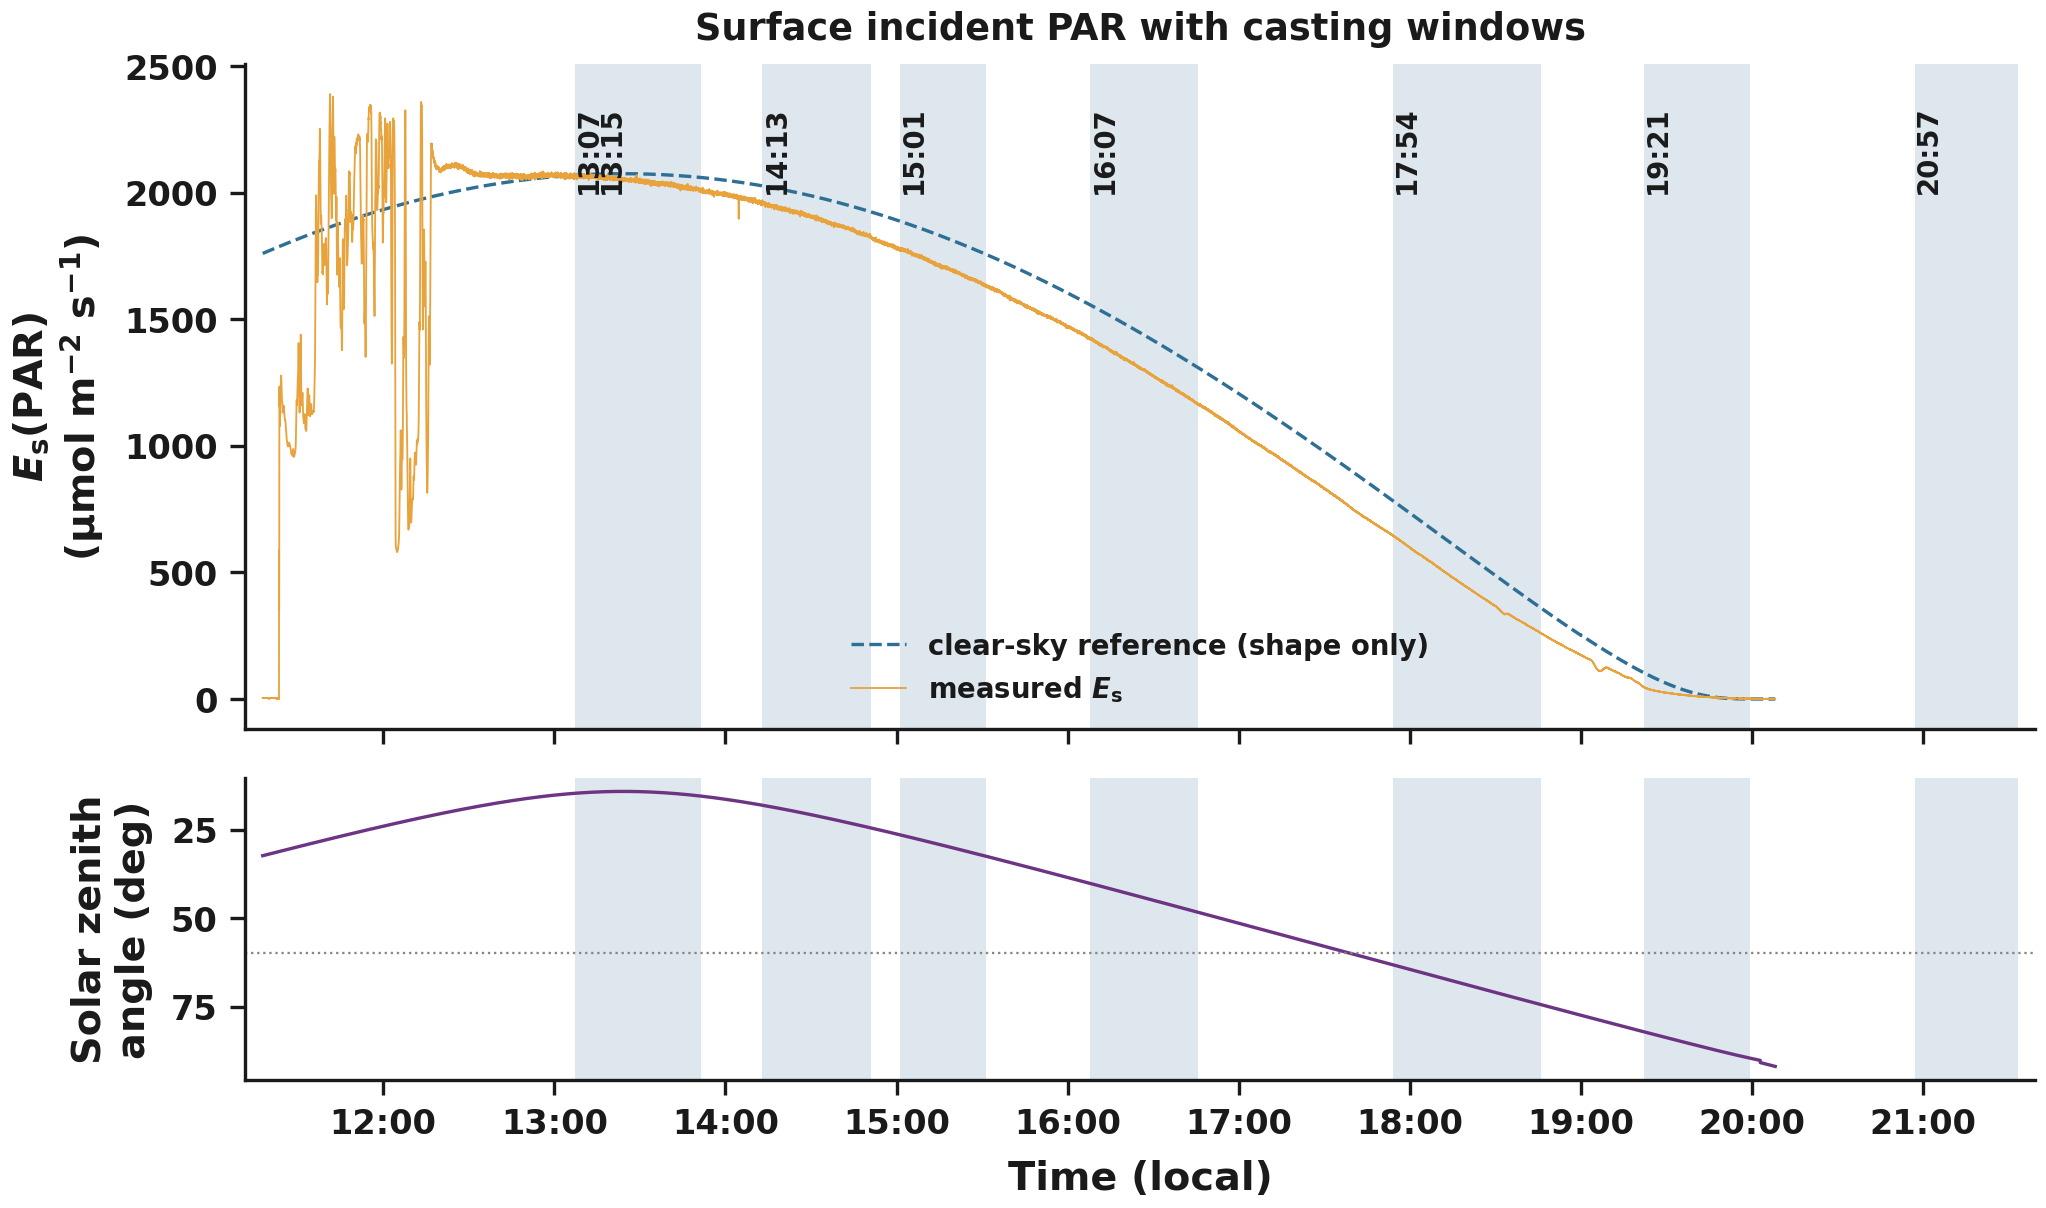

In [35]:
savefig(pio.fig_surface_timeline(surf, stn, qc["gaps"]), "timeline"); plt.show()

## Fig 2 — cloud index and sky steadiness

Rolling CV over a 30 s window, masked to lit samples (at night the mean
approaches zero and the CV explodes). This is the assumption the
single-instrument $K_\mathrm{d}$ fit leans on.

saved cloud_index


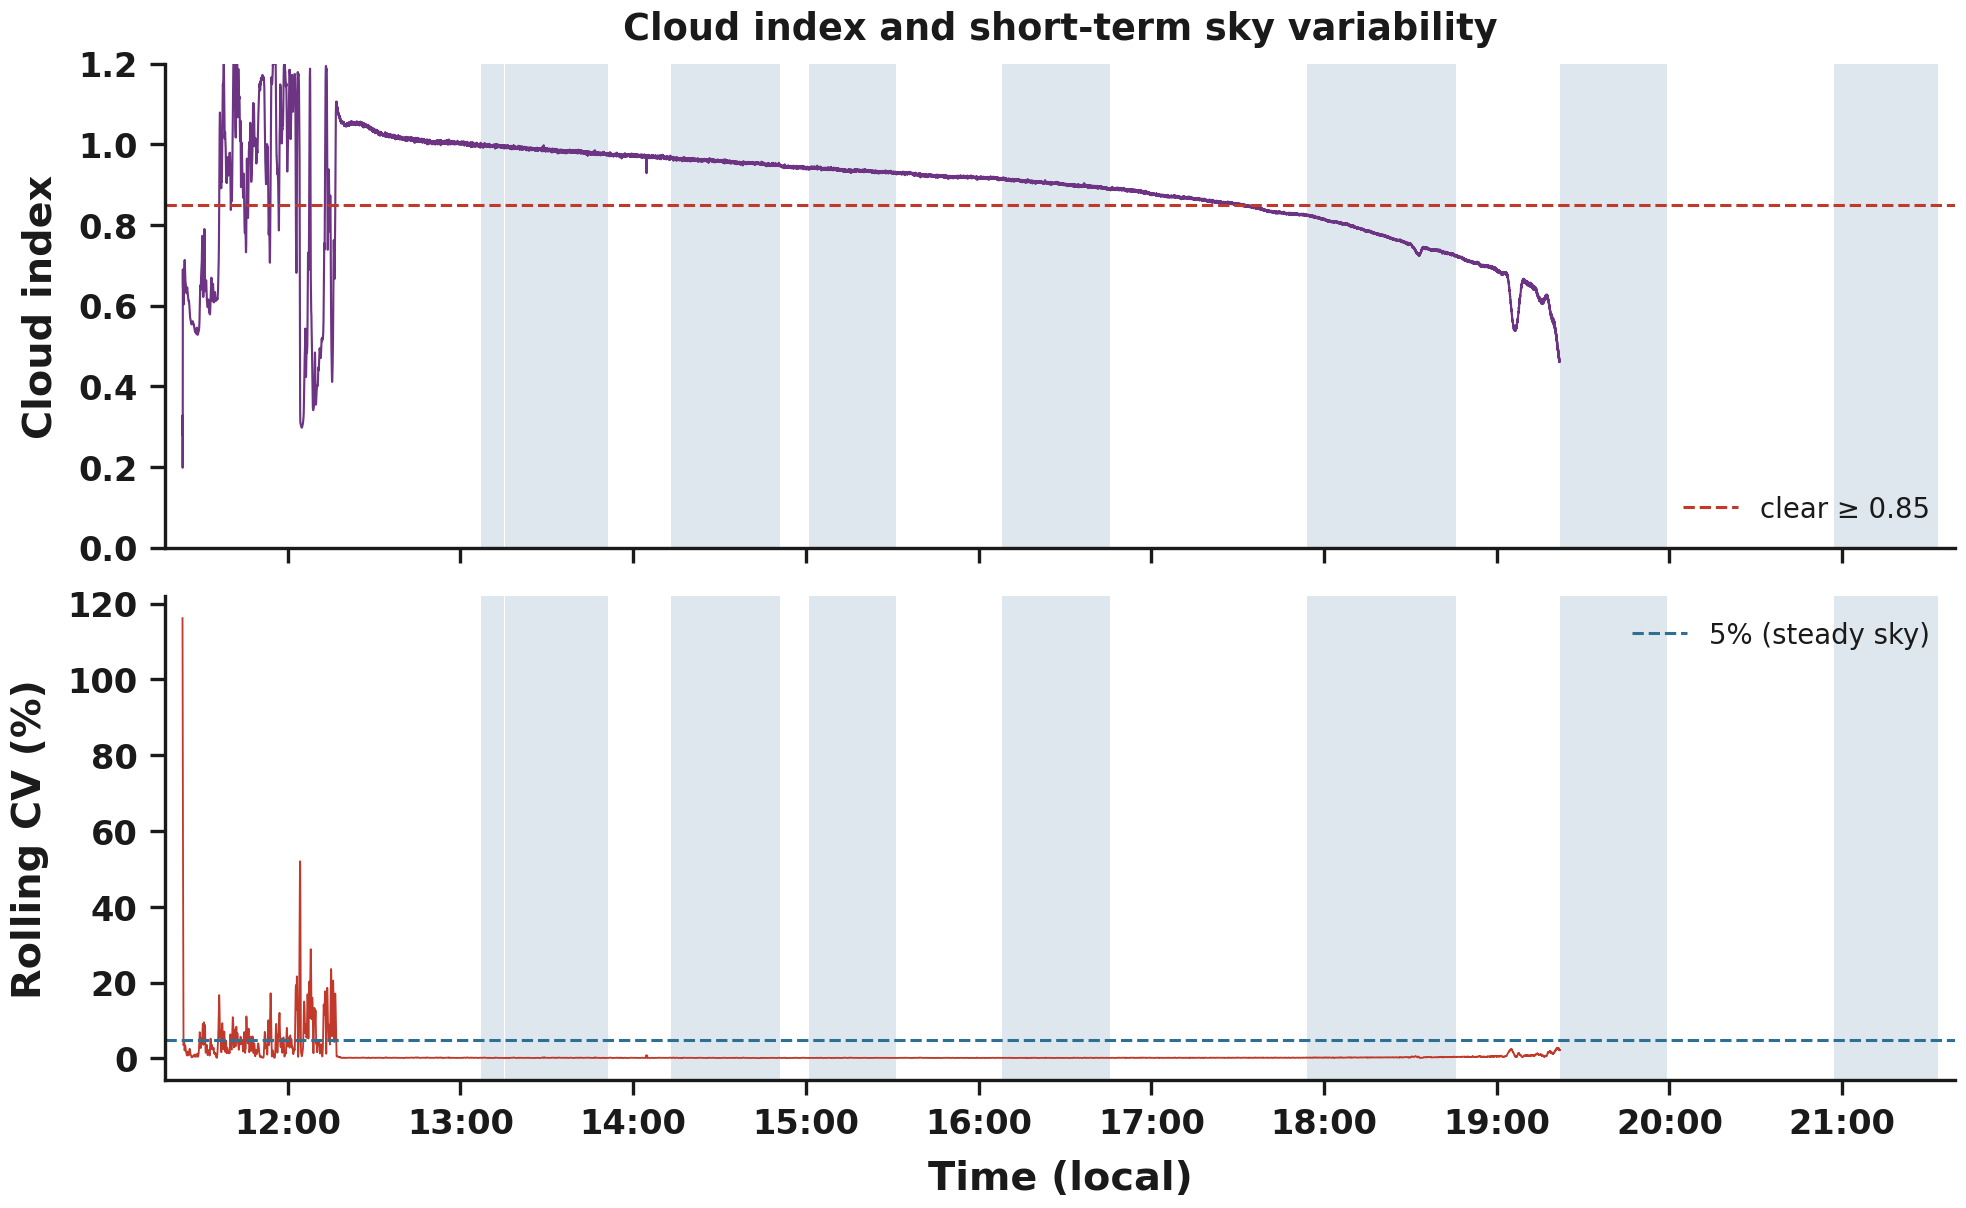

median short-term CV (lit) = 0.2%   (low = steady sky)


In [36]:
cv, win, lit = pio.sky_steadiness(surf, VAR_WINDOW_S)
savefig(pio.fig_cloud_index(surf, cv, stn, CLEAR_THR, STEADY_CV_PCT), "cloud_index")
plt.show()

med = np.nanmedian(cv)
print(f"median short-term CV (lit) = {med:.1f}%   (low = steady sky)")
if np.isfinite(med) and med > STEADY_CV_PCT:
    print("** sky not steady — unnormalised Kd will carry that variability")

## Fig 3 — incident PAR vs sun angle

Morning and afternoon limbs separate where the sky differed between them; a
clear symmetric day collapses them onto one curve.

saved par_vs_sza


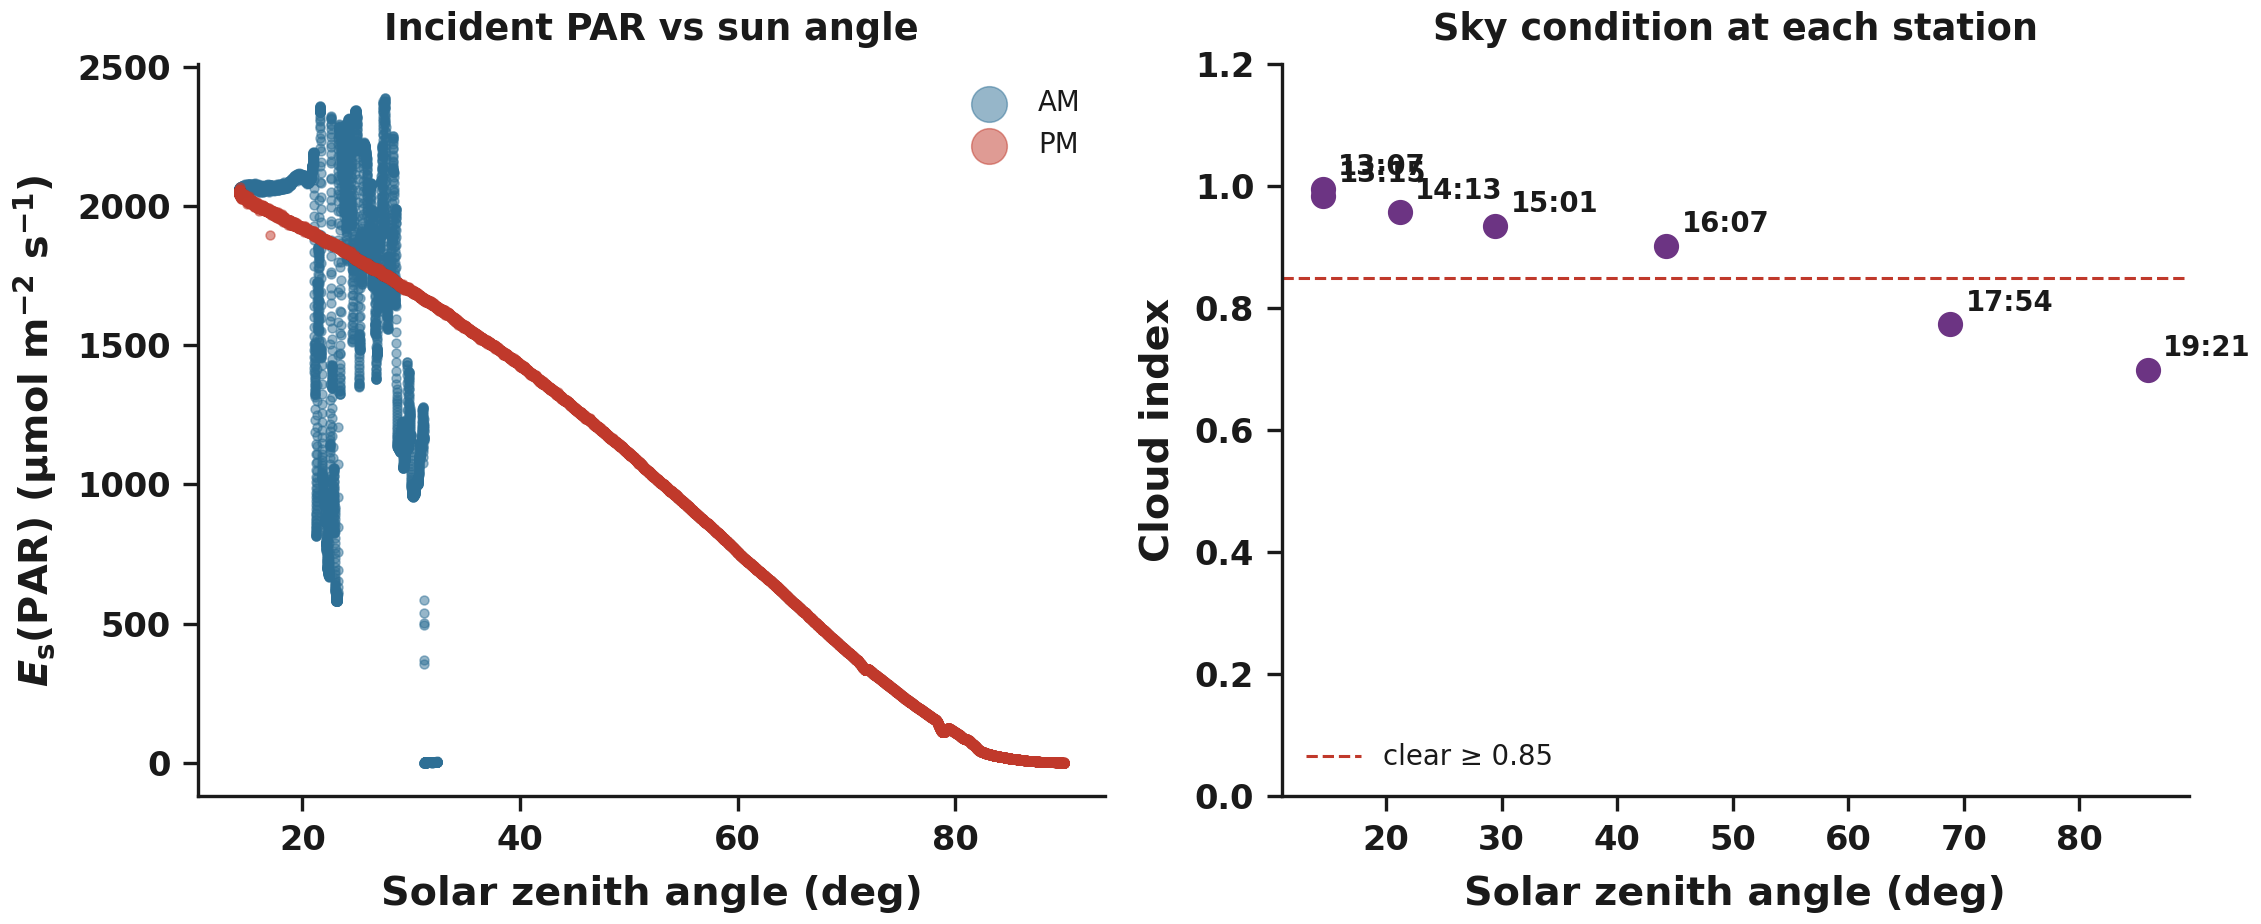

In [37]:
savefig(pio.fig_par_vs_sza(surf, stn, sun["transit"], CLEAR_THR), "par_vs_sza")
plt.show()

## Fig 4 — marine-layer transition

transition ~11:30   cloud index 0.33 → 0.88
saved burnoff


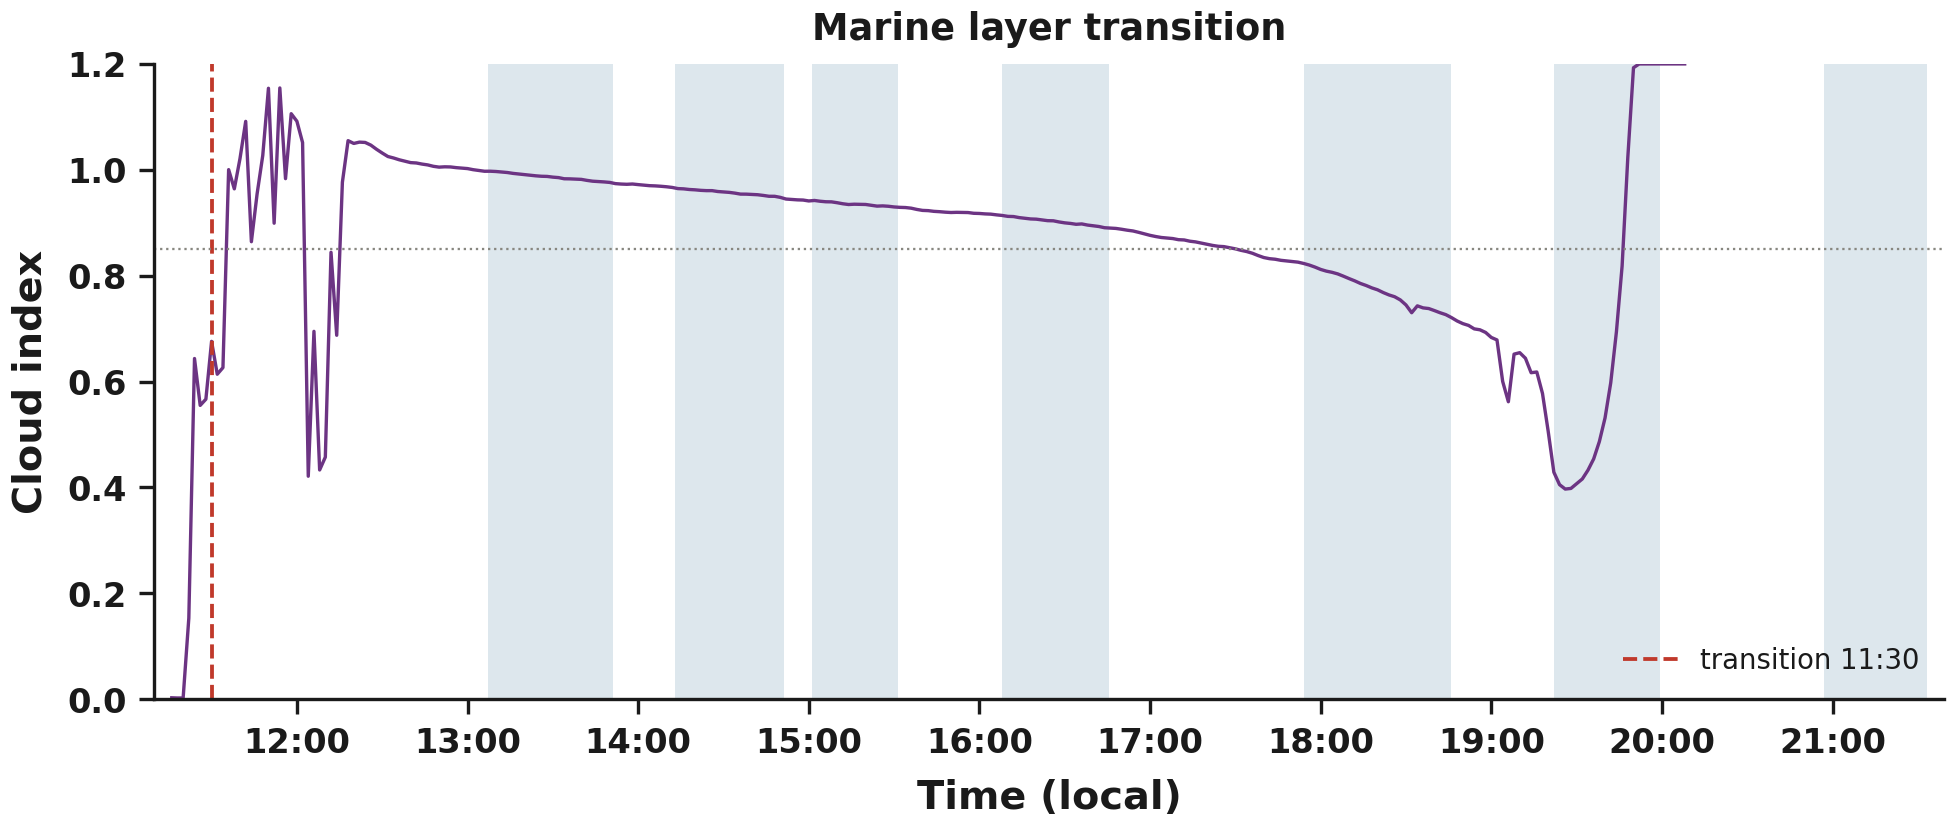

In [38]:
burn = pio.detect_burnoff(surf)
if burn:
    print(f"transition ~{burn['time']:%H:%M}   cloud index "
          f"{burn['before']:.2f} → {burn['after']:.2f}")
    savefig(pio.fig_burnoff(burn, stn, CLEAR_THR), "burnoff"); plt.show()
else:
    print("record too short to detect a transition")

## Fig 5 — distribution and dark floor

saved distribution


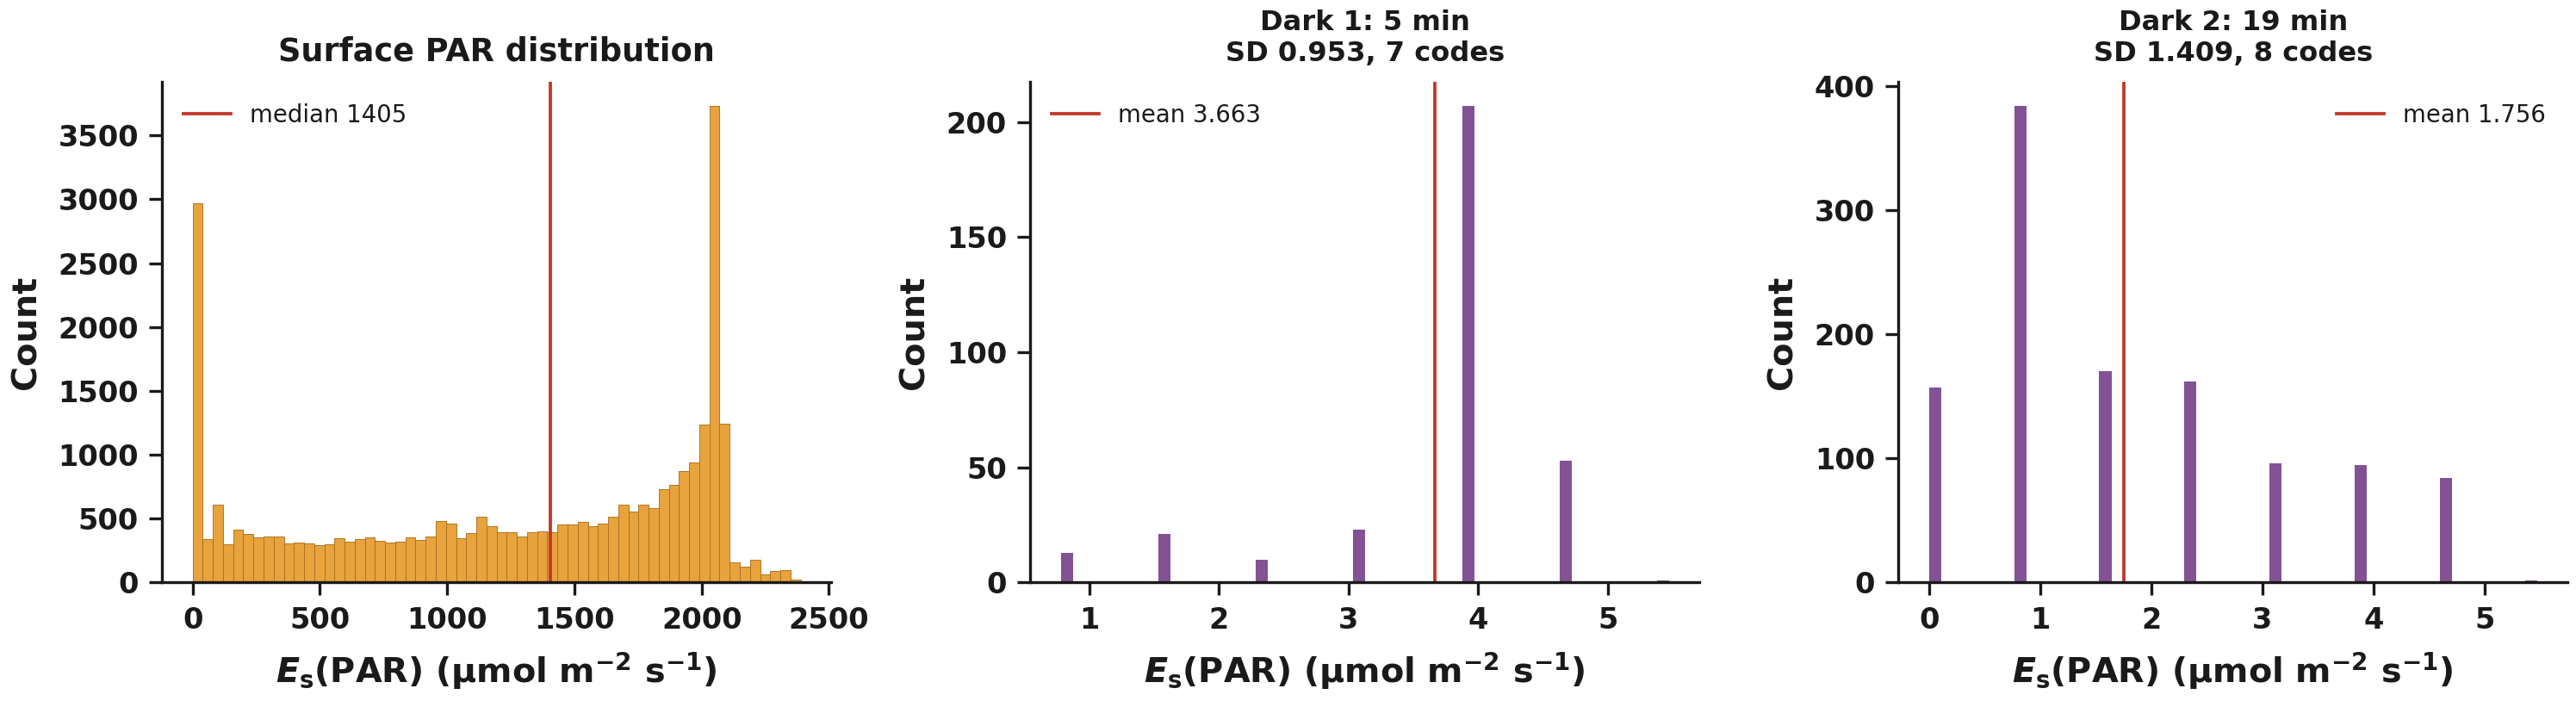

In [39]:
savefig(pio.fig_surface_distribution(surf, dark_tbl), "distribution"); plt.show()

## Export

In [40]:
es = surf.set_index("iso_time")["Es"].resample("1s").mean().interpolate(limit=5)
es.rename("Es").to_frame().to_csv(os.path.join(OUTDIR, f"es_series_{STEM}.csv"))
surf[["iso_time","Es","clear_ref","cloud_index","sza","sky_class"]].to_csv(
    os.path.join(OUTDIR, f"cloud_index_{STEM}.csv"), index=False)
stn.to_csv(os.path.join(OUTDIR, f"station_sky_{STEM}.csv"), index=False)
print(f"saved es_series, cloud_index, station_sky -> {OUTDIR}")
print(f"peak Es {surf.Es.max():.0f} at {surf.iso_time[surf.Es.idxmax()]:%H:%M}")

saved es_series, cloud_index, station_sky -> /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR_day
peak Es 2389 at 11:41


---
Ineichen, P. & Perez, R. (2002). *Solar Energy* 73(3), 151–157.
Reda, I. & Andreas, A. (2004). *Solar Energy* 76(5), 577–589.